In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATASET_PATH = BASE_DIR / "receipts" / "train"

IMG_PATH = DATASET_PATH / "img"
LABEL_PATH = DATASET_PATH / "entities"

images = list(IMG_PATH.glob("*.jpg"))
print(len(images))

681


(np.float64(-0.5), np.float64(462.5), np.float64(1012.5), np.float64(-0.5))

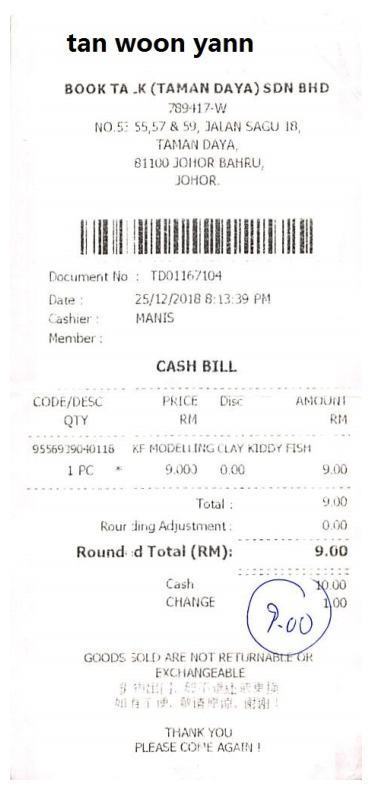

In [4]:
import cv2
import matplotlib.pyplot as plt

sample_image_path = images[0]

image = cv2.imread(str(sample_image_path))

plt.figure(figsize=(6,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [5]:
import pytesseract

data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

len(data["text"])

143

In [6]:
for i in range(20):
    print(data["text"][i], data["conf"][i])

 -1
 -1
 -1
 -1
tan 92
woon 92
yann 92
 -1
 -1
 -1
BOOK 95
TAK 4
(TAMAN 92
DAYA) 92
SDN 96
BHD 50
 -1
PBO4N7-W 0
 -1
NO.5? 30


In [7]:
# Cleaning OCR output. Filtering out low-confidence tokens.

words = []

for i, text in enumerate(data["text"]):
    text = text.strip()
    
    if not text:
        continue
        
    conf = int(data["conf"][i])
    
    if conf < 40:
        continue
        
    x = data["left"][i]
    y = data["top"][i]
    w = data["width"][i]
    h = data["height"][i]
    
    words.append({
        "text": text,
        "conf": conf / 100,
        "bbox": [x, y, x+w, y+h]
    })

In [8]:
# Reconstructing text

tokens = [w["text"] for w in words]
text = " ".join(tokens)

print(text[:500])

tan woon yann BOOK (TAMAN DAYA) SDN BHD 55,57 & 59, JALAN SAGU 18, TAMAN DAYA 81100 JOHOR BAHRU, JOHOR. Document No : Date 25/12/2018 8:13:39 PM Cashier MANIS Member CASH BILL CODE/DESC PRICE — Disc Quy RM RM 9556939040118 KF MODELLING CLAY KIDDY FISH 9.00) 6,00 9.00 Total 9,00 Rour ding Adjustment 0.00 Round::d Total (RM): 9.60 Cash CHANGE GOODS SOLD ARE NOT RETURNAP EXCHANGEABLE THANK YOU PLEASE COME AGATY


(np.float64(-0.5), np.float64(462.5), np.float64(1012.5), np.float64(-0.5))

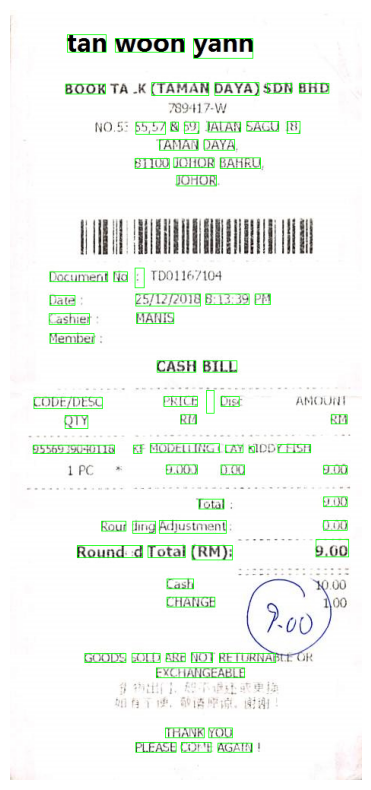

In [9]:
# Visualizing OCR boxes

debug_image = image.copy()

for w in words:
    x1, y1, x2, y2 = w["bbox"]
    cv2.rectangle(debug_image, (x1, y1), (x2, y2), (0,255,0), 1)

plt.figure(figsize=(6,10))
plt.imshow(cv2.cvtColor(debug_image, cv2.COLOR_BGR2RGB))
plt.axis("off")